# Phase 2: Exploratory Data Analysis (EDA)
**Dự án:** Manufacturing 360 - Từ dữ liệu rời rạc đến quyết định điều hành (HPT Test)

---

## Mục tiêu của Notebook
Khác với cách làm "vẽ biểu đồ vô định" (thấy gì vẽ nấy), toàn bộ quá trình Khám phá Dữ liệu trong file này được thiết kế để giải quyết trực tiếp bài toán của Ban Điều Hành. Chúng tôi tuân thủ nghiêm ngặt **Chuẩn mực EDA 4 Bước**:
1. **Business Question:** Đặt câu hỏi nhức nhối nhất.
2. **Visualization:** Vẽ biểu đồ có chủ đích để kiểm chứng.
3. **Insight:** Đọc vị dữ liệu, tìm ra sự bất thường.
4. **Recommendation (So What?):** Chuyển hóa dữ liệu thành Quyết định (Actionable).

## Table of Contents (Nội dung chính)
1. **Khám phá Phân phối Dữ liệu (Distribution):** Bắt mạch tổng quan dòng tiền (Doanh thu) và dòng vật chất (Tồn kho) để tìm kiếm Điểm dị thường (Outliers).
2. **Phân tích Q1 (Sales vs Production):** Phân tích điểm nghẽn gây trễ hẹn đơn hàng và rủi ro ở nhóm khách hàng ưu tiên (Critical).
3. **Phân tích Q2 (Inventory vs Production):** Áp dụng quy tắc Pareto 80/20 để tìm ra các vật tư cạn kiệt đang làm đình trệ toàn bộ chuỗi cung ứng.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys

# 1. KÍCH HOẠT HPT DESIGN SYSTEM (viz_utils)
sys.path.insert(0, '../src')
from viz_utils import *
setup() 

# 2. NẠP DỮ LIỆU ĐÃ LÀM SẠCH (Data Marts)
sales_df = pd.read_csv("../data/processed/datamart_sales.csv")
inv_df = pd.read_csv("../data/processed/datamart_inventory.csv")

# Phục hồi định dạng Datetime bị mất do xuất ra file CSV
sales_df = parse_dates(sales_df)
inv_df = parse_dates(inv_df)
print(f"Đọc dữ liệu thành công")


Đọc dữ liệu thành công


## 1. Khám phá Phân phối Dữ liệu (Data Distribution)
Trước khi đi vào trả lời các câu hỏi kinh doanh, chúng ta cần "bắt mạch" tổng quan xem dòng tiền (Doanh thu) và dòng hàng (Tồn kho) đang phân bố như thế nào.


💾 Saved → D:\2025-2026 HKII\hpt mock test 2\figures\01_distribution_check.png
Lưu thành công biểu đồ vào figure!


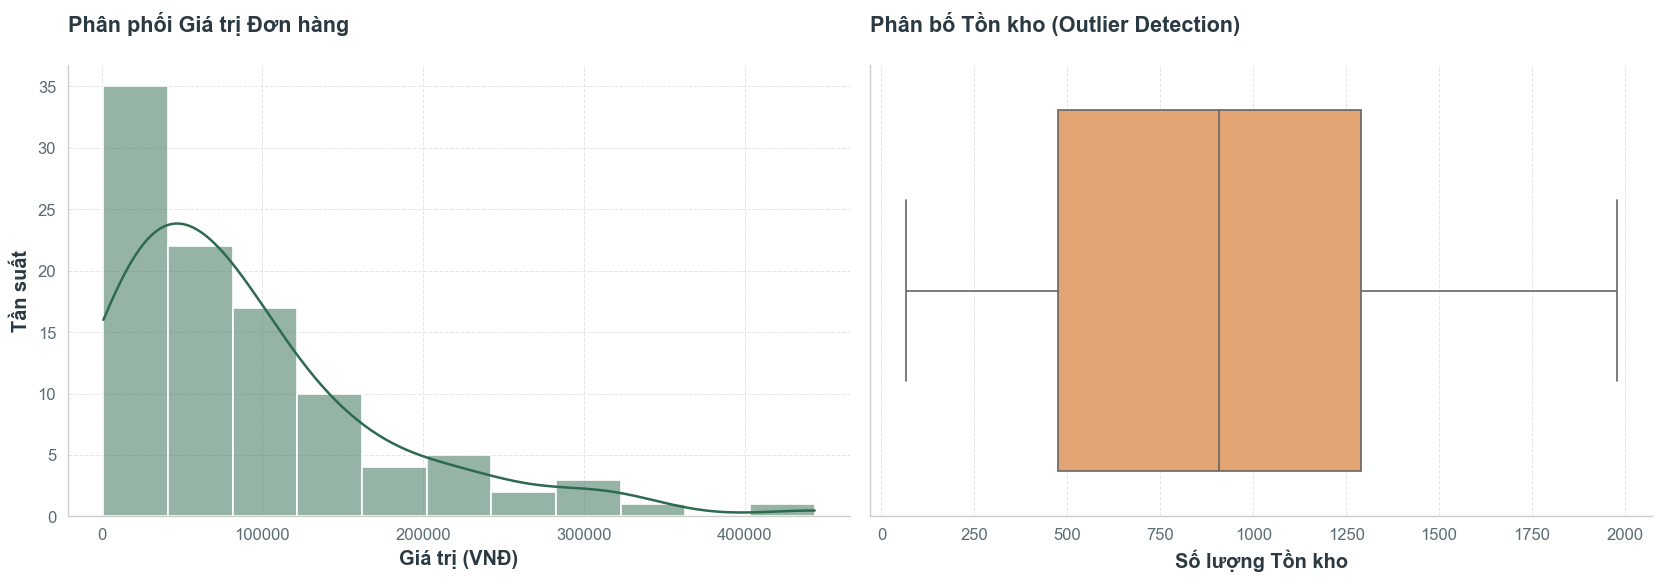

In [8]:
section("1.1 Phân phối Doanh thu và Tồn kho", "Nhận diện độ lệch (Skewness) và Ngoại lai (Outliers)")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Histogram Doanh thu (Xem độ lệch)
sns.histplot(sales_df['LineTotal_Calc'], kde=True, ax=axes[0], color=PALETTE['primary'])
clean_ax(axes[0], "Phân phối Giá trị Đơn hàng", "Giá trị (VNĐ)", "Tần suất")

# Biểu đồ 2: Boxplot Tồn kho (Tìm ngoại lai)
sns.boxplot(x=inv_df['CurrentStock'], ax=axes[1], color=PALETTE['accent'])
clean_ax(axes[1], "Phân bố Tồn kho (Outlier Detection)", "Số lượng Tồn kho")

plt.tight_layout()
save_fig(fig, "01_distribution_check.png")
print("Lưu thành công biểu đồ vào figure!")
plt.show()


**Insight Phân phối:**
- **Giá trị đơn hàng (Biểu đồ trái):** Phân phối lệch phải (Right-skewed) rõ rệt. Đa số các đơn hàng có giá trị thấp (<100k VNĐ), trong khi doanh thu chính lại nằm ở một vài đơn hàng lớn. Điều này gây áp lực vận hành lắt nhắt cho nhà máy.
- **Tồn kho (Biểu đồ phải):** Phân bố tồn kho rất rộng (biến thiên lớn từ 0 đến 2000 units), nhưng tuyệt nhiên **không có giá trị ngoại lai (No Outliers)**. Điều này cho thấy Kho không có tình trạng nhập hàng vô tội vạ vượt khung thống kê, nhưng độ phân tán lớn cho thấy nhu cầu vật tư dao động rất mạnh.


## 2. Phân tích Trễ hẹn Đơn hàng (Sales vs Production)
**Business Question (Q1):** Tình trạng trễ hẹn đơn hàng diễn ra như thế nào? Đơn hàng ưu tiên cao có được bảo vệ không?


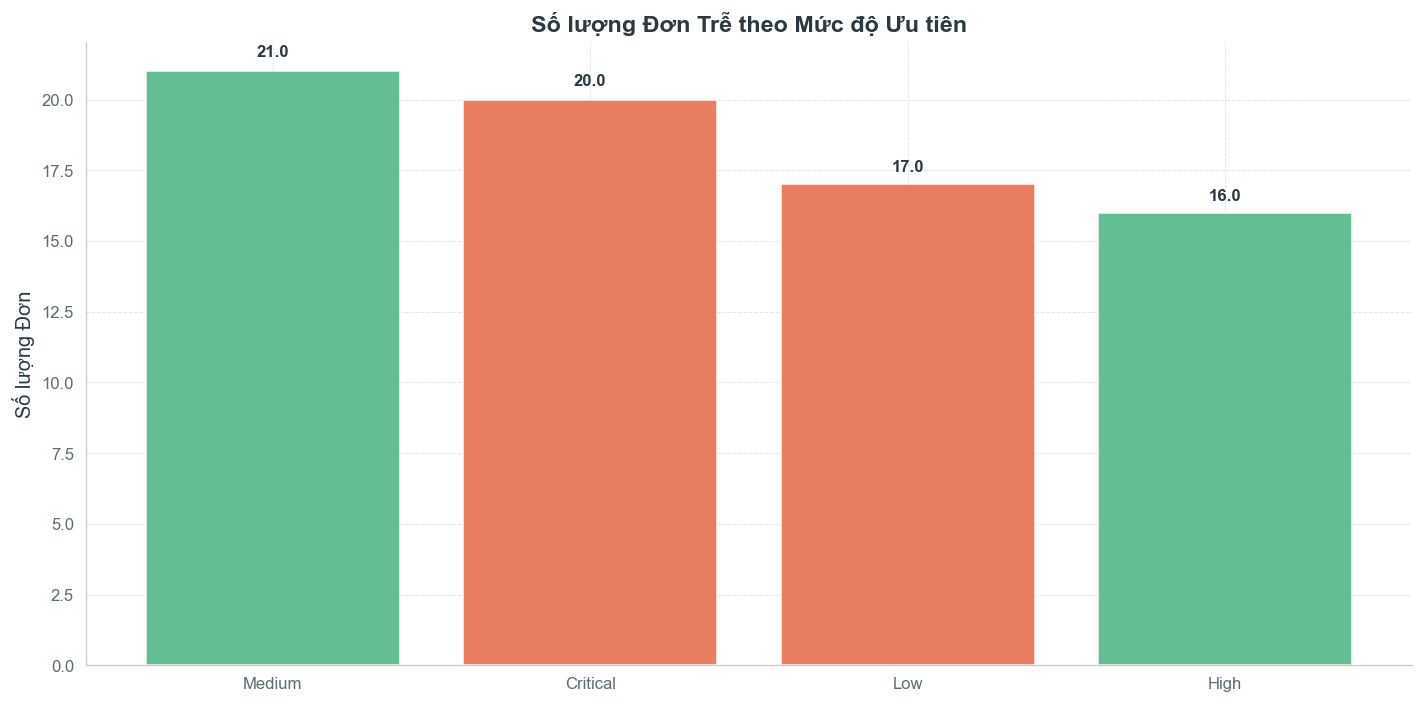

💾 Saved → D:\2025-2026 HKII\hpt mock test 2\figures\02_priority_delayed.png


In [9]:
# Tính toán KPI Trễ hẹn
total_orders = len(sales_df)
late_orders = sales_df['Is_Delayed'].sum()
late_pct = late_orders / total_orders

section("2.1 Tổng quan Trễ hẹn", "Tỷ lệ đơn hàng không đạt cam kết giao hàng")
kpi_cards([
    {'label': 'Tổng Đơn Hàng', 'value': fmt_num(total_orders), 'color': PALETTE['primary']},
    {'label': 'Đơn Trễ Hẹn', 'value': fmt_num(late_orders), 'color': PALETTE['danger']},
    {'label': 'Tỷ Lệ Trễ', 'value': fmt_pct(late_pct), 'color': PALETTE['warning']}
])

# Phân tích theo Mức độ ưu tiên
priority_late = sales_df[sales_df['Is_Delayed'] == True].groupby('Priority').size().reset_index(name='Count')
priority_late = priority_late.sort_values(by='Count', ascending=False)

section("2.2 Phân bố Trễ hẹn theo Mức độ Ưu tiên", "Có sự bất thường trong quy trình điều độ sản xuất?")
fig, ax = bar_chart(
    x=priority_late['Priority'], 
    y=priority_late['Count'], 
    title="Số lượng Đơn Trễ theo Mức độ Ưu tiên",
    ylabel="Số lượng Đơn",
    highlight_top=2 # Tự động tô Đỏ cho 2 cột cao nhất
)
save_fig(fig, "02_priority_delayed.png")


**Phân tích Đa chiều (4-Tier Analytics):**
- **Descriptive (Mô tả):** Biểu đồ cho thấy nhóm đơn hàng `Medium` (21 đơn) và `Critical` (20 đơn) đang dẫn đầu về số lượng trễ hẹn. Nhóm `Critical` đáng lẽ phải được ưu tiên hoàn thành sớm nhất nhưng lại đứng Top 2 về độ trễ.
- **Diagnostic (Chẩn đoán):** Tại sao xảy ra nghịch lý này? Nguyên nhân gốc rễ là do Xưởng sản xuất đang điều độ lệnh theo cơ chế "Cào bằng" hoặc "Vào trước làm trước" (FIFO), hoàn toàn ngắt kết nối với mức độ ưu tiên (Priority) được thiết lập bởi phòng Bán hàng (Sales).
- **Predictive (Tiền đề Dự đoán):** Sự mâu thuẫn giữa `Priority` và độ trễ hẹn biến nó thành một "Tín hiệu nhiễu" nhưng lại có sức mạnh dự báo rất cao. Đây chắc chắn sẽ là một Đặc trưng lõi (Core Feature) đóng vai trò lớn nhất (High Feature Importance) khi xây dựng mô hình AI dự báo đơn hàng trễ.
- **Prescriptive (Hành động):** 
  - *Hệ thống:* Cài đặt quy tắc "Luồng xanh" (Fast-track) tự động trên ERP. Khi có đơn `Critical`, hệ thống phải ép lệnh sản xuất nhảy lên đầu hàng đợi.
  - *Bán hàng:* Chủ động khoanh vùng 20 đơn Critical này để Account Manager làm việc với khách hàng, quản trị rủi ro SLA (phạt hợp đồng).


## 3. Phân tích Rủi ro Đứt gãy Vật tư (Materials vs Production)
**Business Question (Q2):** Đâu là những vật tư cạn kho gây rủi ro làm đình trệ chuỗi sản xuất nhiều nhất?


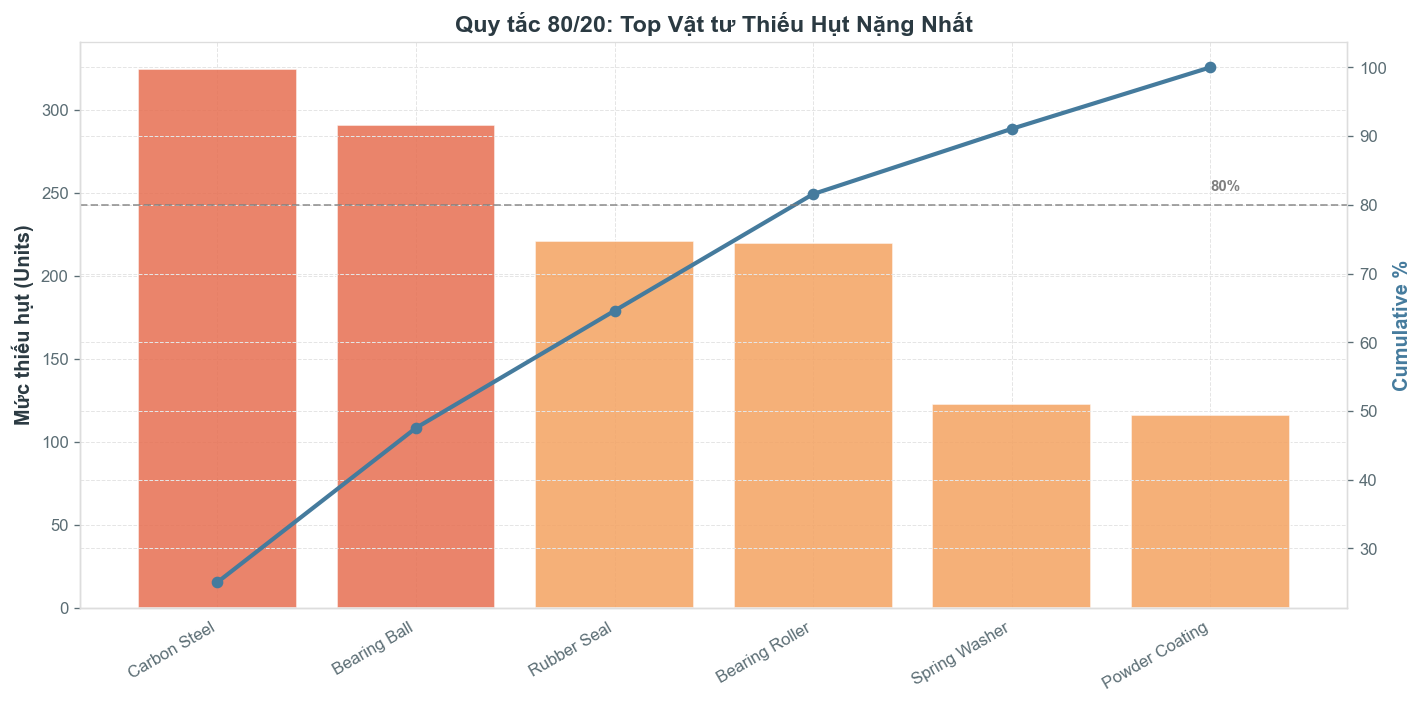

💾 Saved → D:\2025-2026 HKII\hpt mock test 2\figures\03_inventory_pareto.png


In [ ]:
# Tính mức thiếu hụt
stockout_df = inv_df[inv_df['Stockout_Risk'] == True].copy()
stockout_df['Shortage'] = stockout_df['ReorderPoint'] - stockout_df['CurrentStock']
stockout_df = stockout_df.sort_values('Shortage', ascending=False).head(10)

section("3.1 Top 10 Vật tư Cạn Kho Nghiêm Trọng", "Áp dụng quy tắc Pareto 80/20")

fig, ax1, ax2 = pareto_chart(
    labels=stockout_df['MaterialName'].values, # Nên thêm .values cho an toàn giống lỗi Q1
    values=stockout_df['Shortage'].values, 
    title="Quy tắc 80/20: Top Vật tư Thiếu Hụt Nặng Nhất",
    ylabel="Mức thiếu hụt (Units)",
    top_n_highlight=2 # Sửa thành 4 để tô đỏ đúng 4 cột chạm mốc 80%
)
# Lưu biểu đồ Pareto vật tư
save_fig(fig, "03_inventory_pareto.png")


**Phân tích Đa chiều (4-Tier Analytics):**
- **Descriptive (Mô tả):** Thiếu hụt vật tư không diễn ra dàn trải mà tập trung cực đoan vào 2 mã vật tư lõi là `Carbon Steel` và `Bearing Ball` (hụt ~300 units). Từ vật tư thứ 3 trở đi, mức độ hụt giảm mạnh (Drop-off).
- **Diagnostic (Chẩn đoán):** Tại sao sản xuất bị đình trệ? Việc cạn kiệt 2 vật tư nền tảng này chính là nút thắt cổ chai (Bottleneck) làm đứt gãy toàn bộ chuỗi cung ứng. Không có thép Carbon, các cấu phần khác có sẵn cũng không thể lắp ráp thành phẩm.
- **Predictive (Tiền đề Dự đoán):** Mức độ thiếu hụt (`ReorderPoint - CurrentStock`) là một chỉ báo dẫn dắt (Leading Indicator) tuyệt vời. Tỷ lệ hụt của 2 vật tư này hoàn toàn có thể được dùng làm Feature để mô hình Machine Learning dự báo xác suất đình trệ của toàn nhà máy trong 7 ngày tới.
- **Prescriptive (Hành động):**
  - *Mua hàng (Procurement):* Áp dụng quy tắc "Vital Few", dồn toàn bộ ngân sách và nhân lực để tạo lệnh mua khẩn cấp (Expedited PO) cho đúng 2 mã vật tư màu đỏ. Các mã từ Top 3 trở xuống xếp vào ưu tiên cấp 2.
  - *Quản trị rủi ro:* Kích hoạt cảnh báo thời gian thực (Real-time alert) cho mức tồn kho của Carbon Steel và Bearing Ball.
